# **1) RUN THE FOLLOWING CODE BLOCKS AS IS**

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import pytorch_lightning as pl
from pytorch_lightning import LightningModule
from transformers import MistralModel, MistralConfig, GPT2Model, GPT2Config
from mamba_ssm import Mamba2 as Mamba
from filterpy.kalman import KalmanFilter
# Set random seeds for reproducibility
seed = 42
global rng
rng = np.random.default_rng(seed)
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


/home/awt36/anaconda3/envs/MambaAMD/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading tilelang libs from dev root: /home/awt36/tilelang/build


Using device: cuda


In [2]:
# 2. System Dynamics Model (LTI Filtering System)
class FilterSim:
    """
    LTI system simulator with configurable dynamics.
    Parameters:
    - nx: state dimension
    - ny: output dimension
    - sigma_w: process noise std
    - sigma_v: measurement noise std
    - A: system matrix (if None, will be randomly generated)
    - C: output matrix (if None, will be randomly generated)
    """
    def __init__(self, nx=10, ny=5, sigma_w=0.1, sigma_v=0.1, A=None, C=None,
                 eig_low=0.5, eig_high=0.8):
        self.nx = nx
        self.ny = ny
        self.sigma_w = sigma_w
        self.sigma_v = sigma_v
        # Generate random stable system matrix if not provided
        if A is None:
            self.A = self._generate_random_stable_matrix(nx, eig_low=eig_low, eig_high=eig_high)
        else:
            self.A = A
        # Generate random observable matrix if not provided
        if C is None:
            self.C = self._generate_observable_C(nx, ny, self.A)
        else:
            self.C = C
    @staticmethod
    def _generate_random_stable_matrix(n, eig_low=0.5, eig_high=0.8, max_tries=1000):
        """Generate a random stable matrix with eigenvalues in [eig_low, eig_high]"""
        for _ in range(max_tries):
            # Generate random eigenvalues in the stable region
            eigs = rng.uniform(eig_low, eig_high, size=n)
            Lambda = np.diag(eigs)
            # Generate random invertible matrix
            P = rng.standard_normal(size=(n,n))
            if np.linalg.matrix_rank(P) == n:
                A = P @ Lambda @ np.linalg.inv(P)
                # Check spectral radius for stability
                if np.max(np.abs(np.linalg.eigvals(A))) < 0.95:
                    return A
        # Fallback: diagonal matrix
        return np.diag(rng.uniform(eig_low, eig_high, size=n))
    @staticmethod
    def _generate_observable_C(nx, ny, A):
        """Generate a random C matrix that ensures observability"""
        for _ in range(100):
            C = rng.standard_normal(size=(ny, nx))
            # Check observability matrix rank
            O = np.concatenate([C @ np.linalg.matrix_power(A, i)
                              for i in range(nx)], axis=0)
            if np.linalg.matrix_rank(O) == nx:
                return C.astype(np.float32)
        raise RuntimeError("Could not generate observable C matrix")
    def simulate(self, traj_len, x0=None):
        """
        Simulate a trajectory.
        Args:
            traj_len: number of time steps
            x0: initial state (if None, random)
        Returns:
            states: (traj_len+1, nx) array of states
            outputs: (traj_len+1, ny) array of noisy observations
        """
        nx, ny = self.nx, self.ny
        # Initialize
        x = rng.standard_normal(size=nx) if x0 is None else x0
        states = [x]
        outputs = [self.C @ x + rng.standard_normal(ny) * self.sigma_v]
        for _ in range(traj_len):
            # State transition with process noise
            x = self.A @ x + rng.standard_normal(size=nx) * self.sigma_w
            states.append(x)
            # Observation with measurement noise
            y = self.C @ x + rng.standard_normal(size=ny) * self.sigma_v
            outputs.append(y)
        return (np.array(states, dtype=np.float32),
                np.array(outputs, dtype=np.float32))
def apply_kalman_filter(fsim, obs, x0=None, P0=None, sigma_w=None, sigma_v=None):
    """
    Apply Kalman filter to a trajectory's observations.
    Args:
        fsim: FilterSim instance with A and C matrices
        obs: (traj_len+1, ny) array of noisy observations
        x0: initial state estimate (if None, uses zeros)
        P0: initial covariance (if None, uses identity)
        sigma_w: process noise (if None, uses fsim.sigma_w)
        sigma_v: measurement noise (if None, uses fsim.sigma_v)
    Returns:
        kf_states: (traj_len+1, nx) array of Kalman filter state estimates
    """
    ny, nx = fsim.C.shape
    sigma_w = fsim.sigma_w if sigma_w is None else sigma_w
    sigma_v = fsim.sigma_v if sigma_v is None else sigma_v
    kf = KalmanFilter(dim_x=nx, dim_z=ny)
    kf.Q = np.eye(nx) * sigma_w ** 2
    kf.R = np.eye(ny) * sigma_v ** 2
    kf.P = np.eye(nx) if P0 is None else P0
    kf.x = np.zeros(nx) if x0 is None else x0
    kf.F = fsim.A
    kf.H = fsim.C
    # Store predictions
    kf_states = []
    # Process first observation y_0 to estimate x_0
    if len(obs) > 0:
        kf.update(obs[0])
        kf_states.append(kf.x.copy())
    # Process remaining observations: predict with u_i, update with y_{i+1}
    for i in range(len(obs)-1):
        kf.predict()
        kf.update(obs[i+1])
        kf_states.append(kf.x.copy())
    return np.array(kf_states, dtype=np.float32)
def apply_kalman_filter_from_traj(traj):
    """
    Apply Kalman filter to a trajectory dictionary.
    Args:
        traj: trajectory dictionary with 'obs', 'A', 'C' (and optionally 'sigma_w', 'sigma_v')
    Returns:
        kf_states: (traj_len+1, nx) array of Kalman filter state estimates
    """
    # Create a FilterSim instance with the trajectory's parameters
    nx = traj['A'].shape[0]
    ny = traj['C'].shape[0]
    # Get noise parameters from trajectory or use defaults
    sigma_w = traj.get('sigma_w', 0.1)
    sigma_v = traj.get('sigma_v', 0.1)
    fsim = FilterSim(nx=nx, ny=ny, sigma_w=sigma_w, sigma_v=sigma_v)
    fsim.A = traj['A']
    fsim.C = traj['C']
    return apply_kalman_filter(fsim, traj['obs'])


In [3]:
# 3. Dataset Preparation
class TrajectoryDataset(Dataset):
    """
    Dataset that provides trajectories for training.
    Each sample is a trajectory with states, observations.
    """
    def __init__(self, trajectories):
        """
        Args:
            trajectories: list of trajectory dicts from generate_trajectory()
        """
        self.trajectories = trajectories
    def __len__(self):
        return len(self.trajectories)
    def __getitem__(self, idx):
        """
        Returns a sample dict with:
        - xs: input features (observation)
        - ys: target (state)
        """
        traj = self.trajectories[idx % len(self.trajectories)]
        states = traj['states']  # (traj_len+1, nx)
        obs = traj['obs']  # (traj_len+1, ny)
        # Input: output_t, Target: state_t
        # Use noisy observations as input
        xs = obs[1:]  # (traj_len, ny)
        ys = states[1:]  # (traj_len, nx)
        return {
            'xs': torch.from_numpy(xs).float(),
            'ys': torch.from_numpy(ys).float()
        }
def create_datasets(num_train=1000, num_val=200, traj_len=50,
                    nx=10, ny=5, sigma_w=0.1, sigma_v=0.1,
                    eig_low=0.5, eig_high=0.9, A=None, B=None, C=None):
    """
    Create training and validation datasets.
    Returns:
        train_dataset, val_dataset
    """
    print("Generating training trajectories...")
    train_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           eig_low=eig_low, eig_high=eig_high)
        for _ in tqdm(range(num_train))
    ]
    print("Generating validation trajectories...")
    val_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           eig_low=eig_low, eig_high=eig_high)
        for _ in tqdm(range(num_val))
    ]
    return TrajectoryDataset(train_traj), TrajectoryDataset(val_traj)
def generate_trajectory(nx=10, ny=5, traj_len=50, sigma_w=0.1, sigma_v=0.1,
                         A=None, C=None,
                         eig_low=0.5, eig_high=0.8):
    """
    Generate a single trajectory with configurable parameters.
    Returns:
        dict with 'states', 'obs', 'A', 'C', 'sigma_w', 'sigma_v'
    """
    fsim = FilterSim(nx=nx, ny=ny, sigma_w=sigma_w, sigma_v=sigma_v, 
                     eig_low=eig_low, eig_high=eig_high,
                    )
    states, obs = fsim.simulate(traj_len)
    return {
        'states': states,
        'obs': obs,
        'A': fsim.A,
        'C': fsim.C,
        'sigma_w': sigma_w,
        'sigma_v': sigma_v
    }


In [4]:
# 4. Mistral Transformer Model
class Mistral7BFilter(LightningModule):
    """
    Transformer model using HuggingFace Mistral for sequence prediction.
    Trained with PyTorch Lightning.
    """
    def __init__(self, input_dim, output_dim, n_positions=50,
                 n_embd=128, n_layer=6, n_head=4, dropout=0.15,
                 learning_rate=1e-4, weight_decay=1e-4, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            n_embd: embedding dimension
            n_layer: number of transformer layers
            n_head: number of attention heads
            dropout: dropout rate
            learning_rate: learning rate for optimizer
            weight_decay: weight decay for optimizer
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.n_embd = n_embd
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip
        # Input embedding (projects input features to embedding dimension)
        self.embed = nn.Linear(input_dim, n_embd)
        # Mistral configuration
        mistral_config = MistralConfig(
            vocab_size=1,  # Not used, we have our own embeddings
            max_position_embeddings=n_positions,
            hidden_size=n_embd,
            num_hidden_layers=n_layer,
            num_attention_heads=n_head,
            num_key_value_heads=n_head,  # Mistral uses GQA by default
            intermediate_size=n_embd * 4,  # Typical for Mistral
            hidden_dropout=dropout,
            attention_dropout=dropout,
            use_cache=False,
        )
        # Mistral model (without the final LM head)
        self.transformer = MistralModel(mistral_config)
        # Output projection
        self.output_proj = nn.Linear(n_embd, output_dim)
        # Loss function
        self.criterion = nn.MSELoss()
    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim) input tensor
        Returns:
            preds: (batch_size, seq_len, output_dim) predictions
        """
        batch_size, seq_len, _ = xs.shape
        # Input embedding
        x = self.embed(xs)
        # Truncate if sequence is too long
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]
        # Mistral expects inputs_embeds, not tokenizer input
        # Mistral has built-in positional embeddings and causal mask
        output = self.transformer(inputs_embeds=x).last_hidden_state
        # Output projection
        preds = self.output_proj(output)
        return preds
    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss
    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss
    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }
# 4b. GPT2 Transformer Model
class GPT2Filter(LightningModule):
    """
    Transformer model using HuggingFace GPT2 for sequence prediction.
    Trained with PyTorch Lightning.
    """
    def __init__(self, input_dim, output_dim, n_positions=50,
                 n_embd=256, n_layer=12, n_head=8, dropout=0.1,
                 learning_rate=3e-4, weight_decay=1e-2, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            n_embd: embedding dimension
            n_layer: number of transformer layers
            n_head: number of attention heads
            dropout: dropout rate
            learning_rate: learning rate
            weight_decay: weight decay
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.n_embd = n_embd
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip
        self.embed = nn.Linear(input_dim, n_embd)
        gpt2_config = GPT2Config(
            n_positions=2048,
            n_embd=n_embd,
            n_layer=n_layer,
            n_head=n_head,
            resid_pdrop=0.0,
            embd_pdrop=0.0,
            attn_pdrop=0.0,
            use_cache=False,
        )
        self.transformer = GPT2Model(gpt2_config)
        self.output_proj = nn.Linear(n_embd, output_dim)
        self.criterion = nn.MSELoss()
    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim)
        Returns:
            preds: (batch_size, seq_len, output_dim)
        """
        batch_size, seq_len, _ = xs.shape
        x = self.embed(xs)
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]
        output = self.transformer(inputs_embeds=x).last_hidden_state
        preds = self.output_proj(output)
        return preds
    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss
    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss
    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }
# 4c. Mamba SSM Model
# 4c. Mamba SSM Model
class MambaFilter(LightningModule):
    """
    Mamba SSM model for sequence prediction.
    Trained with PyTorch Lightning.
    Based on the original repository's approach but using Mamba instead of Transformer.
    """
    def __init__(self, input_dim, output_dim, n_positions=50,
                 d_model=256, n_layers=4, d_state=16, d_conv=4, expand=2,
                 learning_rate=1e-4, weight_decay=1e-4, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            d_model: model dimension
            n_layers: number of Mamba layers
            d_state: state dimension for Mamba
            d_conv: convolution dimension for Mamba
            expand: expansion factor for Mamba
            learning_rate: learning rate for optimizer
            weight_decay: weight decay for optimizer
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.d_model = d_model
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip
        # Input projection to model dimension
        self.input_proj = nn.Linear(input_dim, d_model)
        # Layer norm for input
        self.input_ln = nn.LayerNorm(d_model)
        # Mamba SSM layers
        self.mamba_layers = nn.ModuleList([
            Mamba(
                d_model=d_model,
                d_state=d_state,
                d_conv=d_conv,
                expand=expand
            ) for _ in range(n_layers)
        ])
        # Layer norm between layers
        self.layer_norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])
        # Output projection
        self.output_proj = nn.Linear(d_model, output_dim)
        # Loss function
        self.criterion = nn.MSELoss()
        # Initialize weights properly
        self.apply(self._init_weights)
        # Force all submodules to train mode
        self.train()
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim) input tensor
        Returns:
            preds: (batch_size, seq_len, output_dim) predictions
        """
        batch_size, seq_len, _ = xs.shape
        # Input projection
        x = self.input_proj(xs)  # (batch_size, seq_len, d_model)
        x = self.input_ln(x)
        # Truncate if sequence is too long
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]
        # Apply Mamba layers with layer norm
        for i, layer in enumerate(self.mamba_layers):
            x = layer(x)
            x = self.layer_norms[i](x)
        # Output projection
        preds = self.output_proj(x)
        return preds
    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss
    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss
    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }


In [5]:
# 5. Training Setup
class TransformerDataModule(pl.LightningDataModule):
    """Lightning data module for trajectory data."""
    def __init__(self, train_dataset, val_dataset=None, batch_size=32, num_workers=4):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.batch_size = batch_size
        self.num_workers = num_workers
    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=False,
            drop_last=False
        )
    def val_dataloader(self):
        if self.val_dataset is not None:
            return DataLoader(
                self.val_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=False,
                drop_last=False
            )
        return None
    def test_dataloader(self):
        if hasattr(self, 'test_dataset') and self.test_dataset is not None:
            return DataLoader(
                self.test_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=True,
                drop_last=False
            )
        return None


In [6]:
def evaluate_model(model, dataset, batch_size=32):
    """
    Evaluate model on a dataset.
    Args:
        model: trained Mistral7BFilter
        dataset: TrajectoryDataset to evaluate on
        batch_size: batch size for evaluation
    Returns:
        average MSE loss
    """
    model = model.to(device)
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    criterion = nn.MSELoss()
    total_loss = 0.0
    num_batches = 0
    with torch.no_grad():
        for batch in loader:
            xs = batch['xs'].to(device)
            ys = batch['ys'].to(device)
            preds = model(xs)
            min_len = min(preds.shape[1], ys.shape[1])
            loss = criterion(preds[:, :min_len], ys[:, :min_len])
            total_loss += loss.item()
            num_batches += 1
    return total_loss / num_batches
def generate_test_trajectories(num_test=100, traj_len=50, nx=10, ny=5,
                                sigma_w=0.01, sigma_v=0.01,
                                eig_low=0.5, eig_high=0.8, A=None, B=None, C=None):
    """
    Generate test trajectories with potentially different parameters than training.
    """
    print(f'\nGenerating {num_test} test trajectories...')
    test_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           eig_low=eig_low, eig_high=eig_high,
                           )
        for _ in tqdm(range(num_test))
    ]
    return test_traj
def plot_results(history, test_loss=None, save_path=None):
    """Plot training and validation loss."""
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    if 'val_loss' in history and history['val_loss']:
        plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.title('Training History')
    if test_loss is not None:
        plt.subplot(1, 2, 2)
        plt.bar(['Test Loss'], [test_loss])
        plt.title('Test Performance')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f'Plot saved to {save_path}')
    else:
        try:
            plt.show()
        except:
            pass


# **2) START EDITING PARAMETERS HERE**

In [15]:
# Configuration parameters
CONFIG = {
    # System dimensions
    'nx': 10,           # State dimension
    'ny': 5,            # Output dimension
    # Trajectory parameters
    'traj_len': 50,     # Length of each trajectory
    'num_val': 5000,     # Number of validation trajectories
    'num_test': 2500,    # Number of test trajectories
    'num_train_list': [100, 250, 500, 750, 1000, 1750, 2500, 5000, 7500, 10000, 15000],  # List of training trajectory counts to test
    'selected_models': ['mistral', 'gpt2', 'mamba'],  # Models to train
    # Noise parameters (training)
    'sigma_w_train': 0.01,  # Process noise
    'sigma_v_train': 0.01,  # Measurement noise
    'eig_low_train': 0.4,    # Eigenvalue lower bound
    'eig_high_train': 0.7,   # Eigenvalue upper bound
    # Noise parameters (testing) - can be different!
    'sigma_w_test': 0.01,    # Process noise for testing
    'sigma_v_test': 0.01,    # Measurement noise for testing
    'eig_low_test': 0.4,      # Eigenvalue lower bound for testing
    'eig_high_test': 0.7,    # Eigenvalue upper bound for testing
    # Model parameters
    'n_positions': 50,   # Maximum sequence length
    'n_embd': 128,        # Embedding dimension
    'n_layer': 6,         # Number of transformer layers
    'n_head': 4,          # Number of attention heads
    'dropout': 0.15,       # Dropout rate
    # GPT2 Model parameters
    'gpt2_n_embd': 128,
    'gpt2_n_layer': 6,
    'gpt2_n_head': 4,
    'gpt2_dropout': 0.1,
    'gpt2_learning_rate': 1e-4,
    'gpt2_weight_decay': 1e-4,
    # Mamba Model parameters
    'd_model': 128,
    'n_layers': 6,
    'd_state': 16,
    'd_conv': 4,
    'expand': 2,
    'mamba_learning_rate': 1e-4,
    'mamba_weight_decay': 1e-4,
    'mamba_dropout': 0.1,
    # Training parameters
    'batch_size': 32,
    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'gradient_clip': 1.0,
}
print("="*60)
print("TRANSFORMER FILTER (MISTRAL-7B) - VARYING TRAINING TRAJECTORIES")
print("="*60)
print(f"Configuration: {CONFIG}")
print()


TRANSFORMER FILTER (MISTRAL-7B) - VARYING TRAINING TRAJECTORIES
Configuration: {'nx': 10, 'ny': 5, 'traj_len': 50, 'num_val': 5000, 'num_test': 2500, 'num_train_list': [100, 250, 500, 750, 1000, 1750, 2500, 5000, 7500, 10000, 15000], 'selected_models': ['mistral', 'gpt2', 'mamba'], 'sigma_w_train': 0.01, 'sigma_v_train': 0.01, 'eig_low_train': 0.4, 'eig_high_train': 0.7, 'sigma_w_test': 0.01, 'sigma_v_test': 0.01, 'eig_low_test': 0.4, 'eig_high_test': 0.7, 'n_positions': 50, 'n_embd': 128, 'n_layer': 6, 'n_head': 4, 'dropout': 0.15, 'gpt2_n_embd': 128, 'gpt2_n_layer': 6, 'gpt2_n_head': 4, 'gpt2_dropout': 0.1, 'gpt2_learning_rate': 0.0001, 'gpt2_weight_decay': 0.0001, 'd_model': 128, 'n_layers': 6, 'd_state': 16, 'd_conv': 4, 'expand': 2, 'mamba_learning_rate': 0.0001, 'mamba_weight_decay': 0.0001, 'mamba_dropout': 0.1, 'batch_size': 32, 'num_epochs': 50, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'gradient_clip': 1.0}



In [16]:
# Step 2: Generate shared validation and test datasets (same for all models)
print("\n[2/5] Creating shared validation and test datasets...")
# Validation dataset (same for all training sizes)
_, val_dataset = create_datasets(
    num_train=CONFIG['num_train_list'][0],  # Just need a small number for val
    num_val=CONFIG['num_val'],
    traj_len=CONFIG['traj_len'],
    nx=CONFIG['nx'],
    ny=CONFIG['ny'],
    sigma_w=CONFIG['sigma_w_train'],
    sigma_v=CONFIG['sigma_v_train'],
    eig_low=CONFIG['eig_low_train'],
    eig_high=CONFIG['eig_high_train'],
)
print(f"Validation dataset: {len(val_dataset)} trajectories")
# Test trajectories (same for all models)
test_trajs = generate_test_trajectories(
    num_test=CONFIG['num_test'],
    traj_len=CONFIG['traj_len'],
    nx=CONFIG['nx'],
    ny=CONFIG['ny'],
    sigma_w=CONFIG['sigma_w_test'],
    sigma_v=CONFIG['sigma_v_test'],
    eig_low=CONFIG['eig_low_test'],
    eig_high=CONFIG['eig_high_test'],
)
print(f"Test trajectories: {len(test_trajs)} trajectories")



[2/5] Creating shared validation and test datasets...
Generating training trajectories...


100%|██████████| 100/100 [00:00<00:00, 681.42it/s]


Generating validation trajectories...


100%|██████████| 5000/5000 [00:02<00:00, 2327.05it/s]


Validation dataset: 5000 trajectories

Generating 2500 test trajectories...


100%|██████████| 2500/2500 [00:01<00:00, 2364.03it/s]

Test trajectories: 2500 trajectories


In [ ]:
# Step 3: Train models with different numbers of training trajectories
print("\n[3/5] Training models with varying training trajectory counts...")
# Dictionary to store trained models: key is (model_type, num_train)
trained_models = {}
input_dim = CONFIG['ny']  # observation dimensions
output_dim = CONFIG['nx']  # predict state
# Model configurations for each type
model_configs = {
    'mistral': {
        'class': Mistral7BFilter,
        'params': {
            'n_positions': CONFIG['n_positions'],
            'n_embd': CONFIG['n_embd'],
            'n_layer': CONFIG['n_layer'],
            'n_head': CONFIG['n_head'],
            'dropout': CONFIG['dropout'],
            'learning_rate': CONFIG['learning_rate'],
            'weight_decay': CONFIG['weight_decay'],
            'gradient_clip': CONFIG['gradient_clip'],
        }
    },
    'gpt2': {
        'class': GPT2Filter,
        'params': {
            'n_positions': CONFIG['n_positions'],
            'n_embd': CONFIG['gpt2_n_embd'],
            'n_layer': CONFIG['gpt2_n_layer'],
            'n_head': CONFIG['gpt2_n_head'],
            'dropout': CONFIG['gpt2_dropout'],
            'learning_rate': CONFIG['gpt2_learning_rate'],
            'weight_decay': CONFIG['gpt2_weight_decay'],
            'gradient_clip': CONFIG['gradient_clip'],
        }
    },
    'mamba': {
        'class': MambaFilter,
        'params': {
            'n_positions': CONFIG['n_positions'],
            'd_model': CONFIG['d_model'],
            'n_layers': CONFIG['n_layers'],
            'd_state': CONFIG['d_state'],
            'd_conv': CONFIG['d_conv'],
            'expand': CONFIG['expand'],
            'learning_rate': CONFIG['mamba_learning_rate'],
            'weight_decay': CONFIG['mamba_weight_decay'],
            'gradient_clip': CONFIG['gradient_clip'],
        }
    }
}
# Get selected models from CONFIG
selected_models = CONFIG.get('selected_models', ['mistral', 'gpt2', 'mamba'])
print(f'Selected models: {selected_models}')
for num_train in CONFIG['num_train_list']:
    print(f'\n--- Training with {num_train} training trajectories ---\n')
    # Create training dataset with this many trajectories
    print(f'Generating {num_train} training trajectories...')
    train_traj = [
        generate_trajectory(nx=CONFIG['nx'], ny=CONFIG['ny'], traj_len=CONFIG['traj_len'],
                           sigma_w=CONFIG['sigma_w_train'], sigma_v=CONFIG['sigma_v_train'],
                           eig_low=CONFIG['eig_low_train'], eig_high=CONFIG['eig_high_train'],
                           )
        for _ in tqdm(range(num_train))
    ]
    train_dataset = TrajectoryDataset(train_traj)
    # Train each selected model type
    for model_type in selected_models:
        print(f'\nTraining {model_type} model...')
        # Get model class and parameters
        model_class = model_configs[model_type]['class']
        model_params = model_configs[model_type]['params'].copy()
        model_params.update({'input_dim': input_dim, 'output_dim': output_dim})
        # Create model
        model = model_class(**model_params)
        print(f'{model_type.capitalize()} Model: {model.__class__.__name__}')
        print(f'{model_type.capitalize()} Parameters: {sum(p.numel() for p in model.parameters()):,}')
        # Create data module
        datamodule = TransformerDataModule(
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            batch_size=CONFIG['batch_size'],
            num_workers=4
        )
        # Create trainer
        trainer = pl.Trainer(
            max_epochs=CONFIG['num_epochs'],
            devices="auto",
            accelerator="auto",
            gradient_clip_val=CONFIG['gradient_clip'],
            log_every_n_steps=10,
            enable_progress_bar=True,
            default_root_dir=".",
        )
        # Train
        print(f'Training {model_type} model with {num_train} trajectories...')
        trainer.fit(model, datamodule=datamodule)
        print(f'Training complete. Best val loss: {trainer.callback_metrics.get("val_loss", float("inf")):.6f}')
        # Store trained model with key (model_type, num_train)
        model_key = (model_type, num_train)
        trained_models[model_key] = model
        print(f'{model_type.capitalize()} model with {num_train} training trajectories saved.')
print("\nAll models trained successfully!")



[3/5] Training models with varying training trajectory counts...
Selected models: ['mistral', 'gpt2', 'mamba']

--- Training with 100 training trajectories ---

Generating 100 training trajectories...


100%|██████████| 100/100 [00:00<00:00, 2624.93it/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Training mistral model...
Mistral Model: Mistral7BFilter
Mistral Parameters: 1,576,714
Training mistral model with 100 trajectories...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/awt36/anaconda3/envs/MambaAMD/lib/python3.12/site-packages/pytorch_lightning/core/optimizer.py:378: Found unsupported keys in the optimizer configuration: {'clip_value'}

  | Name        | Type         | Params | Mode 
-----------------------------------------------------
0 | embed       | Linear       | 768    | train
1 | transformer | MistralModel | 1.6 M  | train
2 | output_proj | Linear       | 1.3 K  | train
3 | criterion   | MSELoss      | 0      | train
-----------------------------------------------------
1.6 M     Trainable params
0         Non-trainable params
1.6 M     Total params
6.307     Total estimated model params size (MB)
86        Modules in train mode
0         Modules in eval mode


/home/awt36/anaconda3/envs/MambaAMD/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...


Training mistral model...
Mistral Model: Mistral7BFilter
Mistral Parameters: 1,576,714
Training mistral model with 5000 trajectories...
Epoch 49: 100%|██████████| 157/157 [00:04<00:00, 35.31it/s, v_num=309, train_loss_step=0.328, val_loss=403.0, train_loss_epoch=16.00]  

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 157/157 [00:04<00:00, 34.46it/s, v_num=309, train_loss_step=0.328, val_loss=403.0, train_loss_epoch=16.00]
Training complete. Best val loss: 402.886444
Mistral model with 5000 training trajectories saved.

Training gpt2 model...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type      | Params | Mode 
--------------------------------------------------
0 | embed       | Linear    | 768    | train
1 | transformer | GPT2Model | 7.9 M  | train
2 | output_proj | Linear    | 1.3 K  | train
3 | criterion   | MSELoss   | 0      | train
--------------------------------------------------
7.9 M     Trainable params
0         Non-trainable params
7.9 M     Total params
31.548    Total estimated model params size (MB)
87        Modules in train mode
0         Modules in eval mode


Gpt2 Model: GPT2Filter
Gpt2 Parameters: 7,886,986
Training gpt2 model with 5000 trajectories...
Epoch 44:  38%|███▊      | 60/157 [00:01<00:02, 42.50it/s, v_num=310, train_loss_step=0.118, val_loss=403.0, train_loss_epoch=16.10]   

In [ ]:
# Step 4: Test each model on the shared test set
print("\n[4/5] Testing all models on shared test set...")
# Dictionary to store results: key is (model_type, num_train)
results = {}
# Number of test trajectories to evaluate
num_test_eval = max(100, len(test_trajs))
print(f'Evaluating on {num_test_eval} test trajectories...')
# Get selected models from CONFIG
selected_models = CONFIG.get('selected_models', ['mistral', 'gpt2', 'mamba'])
for num_train in CONFIG['num_train_list']:
    for model_type in selected_models:
        print(f'\n--- Testing {model_type} model trained with {num_train} trajectories ---')
        model_key = (model_type, num_train)
        model = trained_models[model_key]
        model = model.to(device)
        model.eval()
        # Lists to store errors
        all_transformer_errors = []
        all_kalman_errors = []
        # Sample a subset of test trajectories for evaluation
        sampled_test_indices = rng.choice(len(test_trajs), size=num_test_eval, replace=False)
        for traj_idx in sampled_test_indices:
            test_traj = test_trajs[traj_idx]
            states_true = test_traj['states']
            obs = test_traj['obs']
            # Prepare input for model
            xs_for_model = obs[1:]
            xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)
            # Get model predictions
            with torch.no_grad():
                preds_tensor = model(xs_tensor)
            preds = preds_tensor.squeeze(0).cpu().numpy()
            # Get Kalman filter predictions
            kf_states = apply_kalman_filter_from_traj(test_traj)
            kf_preds = kf_states[1:]
            # Compute squared errors
            actual_len = min(preds.shape[0], states_true[1:].shape[0], kf_preds.shape[0])
            # Model squared error
            model_error = np.mean((states_true[1:][:actual_len] - preds[:actual_len]) ** 2)
            all_transformer_errors.append(model_error)
            # Kalman filter squared error
            kf_error = np.mean((states_true[1:][:actual_len] - kf_preds[:actual_len]) ** 2)
            all_kalman_errors.append(kf_error)
        # Compute summary statistics
        avg_model_error = np.mean(all_transformer_errors)
        std_model_error = np.std(all_transformer_errors)
        avg_kf_error = np.mean(all_kalman_errors)
        std_kf_error = np.std(all_kalman_errors)
        results[model_key] = {
            'model_type': model_type,
            'num_train': num_train,
            'avg_model_error': avg_model_error,
            'std_model_error': std_model_error,
            'avg_kalman_error': avg_kf_error,
            'std_kalman_error': std_kf_error,
            'all_model_errors': all_transformer_errors,
            'all_kalman_errors': all_kalman_errors,
            'model': model
        }
        print(f'{model_type.capitalize()} - Avg squared error: {avg_model_error:.6f} +/- {std_model_error:.6f}')
        print(f'Kalman Filter - Avg squared error: {avg_kf_error:.6f} +/- {std_kf_error:.6f}')
print("\nAll models tested successfully!")



[4/5] Testing all models on shared test set...
Evaluating on 2500 test trajectories...

--- Testing mistral model trained with 100 trajectories ---


Mistral - Avg squared error: 45.956314 +/- 894.430237
Kalman Filter - Avg squared error: 0.000394 +/- 0.000642

--- Testing gpt2 model trained with 100 trajectories ---
Gpt2 - Avg squared error: 45.989159 +/- 895.641724
Kalman Filter - Avg squared error: 0.000394 +/- 0.000642

--- Testing mamba model trained with 100 trajectories ---
Mamba - Avg squared error: 46.281345 +/- 895.096375
Kalman Filter - Avg squared error: 0.000394 +/- 0.000642

--- Testing mistral model trained with 250 trajectories ---
Mistral - Avg squared error: 45.992447 +/- 895.075928
Kalman Filter - Avg squared error: 0.000394 +/- 0.000642

--- Testing gpt2 model trained with 250 trajectories ---
Gpt2 - Avg squared error: 45.970592 +/- 894.555908
Kalman Filter - Avg squared error: 0.000394 +/- 0.000642

--- Testing mamba model trained with 250 trajectories ---
Mamba - Avg squared error: 46.175152 +/- 895.717102
Kalman Filter - Avg squared error: 0.000394 +/- 0.000642

--- Testing mistral model trained with 500 traje


[5/5] Reporting results and creating plots...

SUMMARY OF RESULTS
Model        Train      Model Avg Error           Kalman Avg Error         
--------------------------------------------------------------------------------
mistral      100        45.956314                 0.000394                 
gpt2         100        45.989159                 0.000394                 
mamba        100        46.281345                 0.000394                 
mistral      250        45.992447                 0.000394                 
gpt2         250        45.970592                 0.000394                 
mamba        250        46.175152                 0.000394                 
mistral      500        46.028782                 0.000394                 
gpt2         500        46.035927                 0.000394                 
mamba        500        46.186420                 0.000394                 
mistral      750        45.989464                 0.000394                 
gpt2         750

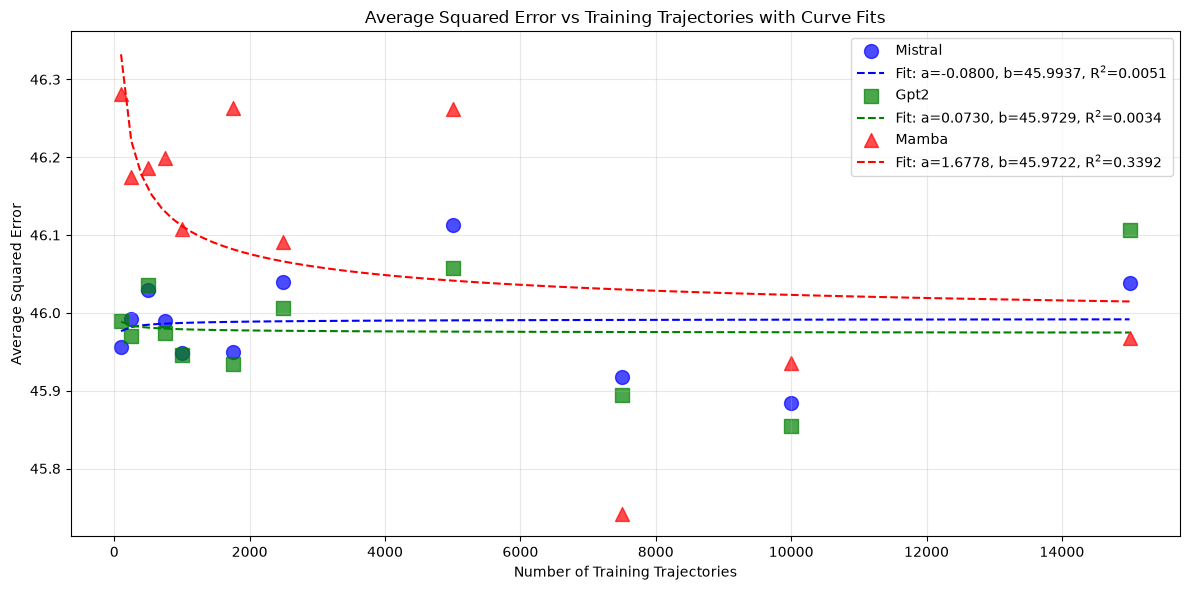


DETAILED RESULTS:


Models trained with 100 trajectories:
  Mistral: avg=45.956314, std=894.430237
  Gpt2: avg=45.989159, std=895.641724
  Mamba: avg=46.281345, std=895.096375

Models trained with 250 trajectories:
  Mistral: avg=45.992447, std=895.075928
  Gpt2: avg=45.970592, std=894.555908
  Mamba: avg=46.175152, std=895.717102

Models trained with 500 trajectories:
  Mistral: avg=46.028782, std=895.734924
  Gpt2: avg=46.035927, std=896.003906
  Mamba: avg=46.186420, std=896.181274

Models trained with 750 trajectories:
  Mistral: avg=45.989464, std=895.384583
  Gpt2: avg=45.974171, std=895.146301
  Mamba: avg=46.198788, std=895.020996

Models trained with 1000 trajectories:
  Mistral: avg=45.947811, std=894.899109
  Gpt2: avg=45.945499, std=895.271118
  Mamba: avg=46.108002, std=895.527283

Models trained with 1750 trajectories:
  Mistral: avg=45.949570, std=892.381042
  Gpt2: avg=45.933834, std=893.136414
  Mamba: avg=46.263542, std=896.201965

Models trained with 2500 trajectori

In [ ]:
# Step 5: Report results and create plots
print("\n[5/5] Reporting results and creating plots...")
# Get selected models from CONFIG
selected_models = CONFIG.get('selected_models', ['mistral', 'gpt2', 'mamba'])
# Print summary table
print("\n" + "="*80)
print("SUMMARY OF RESULTS")
print("="*80)
print(f"{'Model':<12} {'Train':<10} {'Model Avg Error':<25} {'Kalman Avg Error':<25}")
print("-"*80)
for num_train in CONFIG['num_train_list']:
    for model_type in selected_models:
        model_key = (model_type, num_train)
        r = results[model_key]
        print(f"{model_type:<12} {num_train:<10} {r['avg_model_error']:<25.6f} {r['avg_kalman_error']:<25.6f}")
print("="*80)
# Plot: Squared error vs number of training trajectories for each model type
# Each point is a scatterplot point, with curve fit for each model
plt.figure(figsize=(12, 6))
colors = {'mistral': 'blue', 'gpt2': 'green', 'mamba': 'red'}
markers = {'mistral': 'o', 'gpt2': 's', 'mamba': '^'}
from scipy.optimize import curve_fit
def fit_func(x, a, b):
    return a * np.sqrt(np.log(x) / x) + b
for model_type in selected_models:
    train_counts = []
    tf_errors = []
    for num_train in CONFIG['num_train_list']:
        model_key = (model_type, num_train)
        train_counts.append(num_train)
        tf_errors.append(results[model_key]['avg_model_error'])
    # Scatterplot points only
    color = colors.get(model_type, 'blue')
    marker = markers.get(model_type, 'o')
    label = model_type.capitalize()
    plt.scatter(train_counts, tf_errors, s=100, marker=marker, color=color, label=label, alpha=0.7)
    # Fit curve y = a * sqrt(log x / x) + b
    try:
        popt, pcov = curve_fit(fit_func, train_counts, tf_errors)
        a_fit, b_fit = popt
        print(f'\n{model_type.capitalize()} curve: y = {a_fit:.6f} * sqrt(log x / x) + {b_fit:.6f}')
        # Calculate R^2
        y_pred = fit_func(train_counts, a_fit, b_fit)
        ss_res = np.sum((tf_errors - y_pred) ** 2)
        ss_tot = np.sum((tf_errors - np.mean(tf_errors)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        print(f'{model_type.capitalize()} R^2 = {r_squared:.6f}')
        # Generate curve points for plotting
        x_curve = np.linspace(min(train_counts), max(train_counts), 100)
        y_curve = fit_func(x_curve, a_fit, b_fit)
        fit_label = f'Fit: a={a_fit:.4f}, b={b_fit:.4f}, R$^2$={r_squared:.4f}'
        plt.plot(x_curve, y_curve, '--', linewidth=1.5, color=color, label=fit_label)
    except Exception as e:
        print(f'Curve fitting failed for {model_type}: {e}')
plt.xlabel('Number of Training Trajectories')
plt.ylabel('Average Squared Error')
plt.title('Average Squared Error vs Training Trajectories with Curve Fits')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Print detailed results
print("\nDETAILED RESULTS:\n")
for num_train in CONFIG['num_train_list']:
    print(f"\nModels trained with {num_train} trajectories:")
    for model_type in selected_models:
        model_key = (model_type, num_train)
        r = results[model_key]
        print(f"  {model_type.capitalize()}: avg={r['avg_model_error']:.6f}, std={r['std_model_error']:.6f}")
